### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [ ]:
tienda.shape #Conozco la cantidad de filas, columnas

(2359, 12)

In [ ]:
tienda.columns #Resumo los enunciados de las columnas

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

In [ ]:
Datos_nulo = pd.DataFrame({#Realizo la validación de la existencia
#y la cantidad de datos nulos para cada columna en los datos de cada tienda.
    'Tienda 1': tienda.isnull().sum(),
    'Tienda 2': tienda2.isnull().sum(),
    'Tienda 3': tienda3.isnull().sum(),
    'Tienda 4': tienda4.isnull().sum()
})
Datos_nulo

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,0,0,0,0
Categoría del Producto,0,0,0,0
Precio,0,0,0,0
Costo de envío,0,0,0,0
Fecha de Compra,0,0,0,0
Vendedor,0,0,0,0
Lugar de Compra,0,0,0,0
Calificación,0,0,0,0
Método de pago,0,0,0,0
Cantidad de cuotas,0,0,0,0


#1. Análisis de facturación



#### Calculamos el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.

In [ ]:
Ingresos = tienda['Precio'].sum() #En la variable "Ingresos" se almacena del dt tienda, la suma de la columna "Precio"
Ingresos2 = tienda2['Precio'].sum()
Ingresos3 = tienda3['Precio'].sum()
Ingresos4 = tienda4['Precio'].sum()
Ingresos

np.float64(1150880400.0)

In [ ]:
Ingreso = pd.Series({#En la variable "Ingresos" se almacena del dt tienda, la suma de la columna "Precio"
    'Tienda 1': tienda['Precio'].sum(),
    'Tienda 2': tienda2['Precio'].sum(),
    'Tienda 3': tienda3['Precio'].sum(),
    'Tienda 4': tienda4['Precio'].sum()
}, name='Ingreso total (COP)')
Ingresos_ok = Ingreso.map('${:,.2f}'.format)
Ingresos_ok

,Ingreso total (COP)
Tienda 1,"$1,150,880,400.00"
Tienda 2,"$1,116,343,500.00"
Tienda 3,"$1,098,019,600.00"
Tienda 4,"$1,038,375,700.00"


# 2. Ventas por categoría

In [ ]:
#Se filtra "Categoría del Producto" y se cuenta la cantidad de productos vendidos pertenecientes a cada categoría.
Ventas_categoria = tienda.groupby('Categoría del Producto')['Producto'].count()
Ventas_categoria2 = tienda2.groupby('Categoría del Producto')['Producto'].count()
Ventas_categoria3 = tienda3.groupby('Categoría del Producto')['Producto'].count()
Ventas_categoria4 = tienda4.groupby('Categoría del Producto')['Producto'].count()

#Se organizan las filas de mayor a menor valor
Ventas_categoria_AZ = Ventas_categoria.sort_values(ascending=False)
Ventas_categoria2_AZ = Ventas_categoria2.sort_values(ascending=False)
Ventas_categoria3_AZ = Ventas_categoria3.sort_values(ascending=False)
Ventas_categoria4_AZ = Ventas_categoria4.sort_values(ascending=False)

Categorias_total = pd.DataFrame({
    'Tienda 1': Ventas_categoria_AZ,
    'Tienda 2': Ventas_categoria2_AZ,
    'Tienda 3': Ventas_categoria3_AZ,
    'Tienda 4': Ventas_categoria4_AZ
})
Categorias_total

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


# 3. Calificación promedio de la tienda


####Calculamos las calificaciones promedio de los clientes para cada tienda.

In [ ]:
#Asignamos a la variable "Calificación" la calificación promedio para cada tienda con dos difras decimales.
Calificacion = tienda['Calificación'].mean().round(2)
Calificacion2 = tienda2['Calificación'].mean().round(2)
Calificacion3 = tienda3['Calificación'].mean().round(2)
Calificacion4 = tienda4['Calificación'].mean().round(2)

Calificacion


np.float64(3.98)

In [ ]:
Media = pd.Series({
    'Tienda1': Calificacion,
    'Tienda2': Calificacion2,
    'Tienda3': Calificacion3,
    'Tienda4': Calificacion4
}, name='Calificación Promedio')
Media

,Calificación Promedio
Tienda1,3.98
Tienda2,4.04
Tienda3,4.05
Tienda4,4.00


# 4. Productos más y menos vendidos

####Identificamos qué productos fueron los más vendidos y los menos vendidos en cada tienda.

In [ ]:
#Se filtra "Categoría del Producto" y se cuenta la cantidad de productos vendidos pertenecientes a cada categoría.
Ventas_productos = tienda.groupby('Producto')['Producto'].count()
Ventas_productos2 = tienda2.groupby('Producto')['Producto'].count()
Ventas_productos3 = tienda3.groupby('Producto')['Producto'].count()
Ventas_productos4 = tienda4.groupby('Producto')['Producto'].count()

#Se organizan las filas de mayor a menor valor
Ventas_productos_AZ = Ventas_productos.sort_values(ascending=False)
Ventas_productos2_AZ = Ventas_productos2.sort_values(ascending=False)
Ventas_productos3_AZ = Ventas_productos3.sort_values(ascending=False)
Ventas_productos4_AZ = Ventas_productos4.sort_values(ascending=False)

Ventas_productos_AZ.head(5) #Productos más vendidos de la Tienda 1

,Producto
Producto,
Armario,60
TV LED UHD 4K,60
Microondas,60
Secadora de ropa,58
Mesa de noche,56


In [ ]:
Ventas_productos_AZ.tail(5) #Productos menos vendidos de la Tienda 1

,Producto
Producto,
Mochila,39
Pandereta,36
Olla de presión,35
Celular ABXY,33
Auriculares con micrófono,33


In [ ]:
Ventas_productos2_AZ.head(5) #Productos más vendidos de la Tienda 2

,Producto
Producto,
Iniciando en programación,65
Microondas,62
Batería,61
Pandereta,58
Guitarra acústica,58


In [ ]:
Ventas_productos2_AZ.tail(5) #Productos menos vendidos de la Tienda 2

,Producto
Producto,
Auriculares,37
Sillón,35
Impresora,34
Mesa de comedor,34
Juego de mesa,32


In [ ]:
Ventas_productos3_AZ.head(5) #Productos más vendidos de la Tienda 3

,Producto
Producto,
Kit de bancas,57
Mesa de comedor,56
Cama king,56
Set de ollas,55
Mesa de noche,55


In [ ]:
Ventas_productos3_AZ.tail(5) #Productos menos vendidos de la Tienda 3

,Producto
Producto,
Guitarra eléctrica,38
Mochila,36
Microondas,36
Set de vasos,36
Bloques de construcción,35


In [ ]:
Ventas_productos4_AZ.head(5) #Productos más vendidos de la Tienda 4

,Producto
Producto,
Cama box,62
Cubertería,59
Cama king,56
Dashboards con Power BI,56
Carrito de control remoto,55


In [ ]:
Ventas_productos4_AZ.tail(5) #Productos menos vendidos de la Tienda 4

,Producto
Producto,
Ciencia de datos con Python,38
Refrigerador,38
Guitarra acústica,37
Armario,34
Guitarra eléctrica,33


# 5. Envío promedio por tienda

In [ ]:
Envio = tienda['Costo de envío'].mean().round(2)
Envio2 = tienda2['Costo de envío'].mean().round(2)
Envio3 = tienda3['Costo de envío'].mean().round(2)
Envio4 = tienda4['Costo de envío'].mean().round(2)

Envio

np.float64(26018.61)

In [ ]:
Envios = pd.Series({#En la variable "Envios" se almacena la serie pronedio de envíos, el promedio de la columna "Costo de envío"
    'Tienda 1': Envio,
    'Tienda 2': Envio2,
    'Tienda 3': Envio3,
    'Tienda 4': Envio4
}, name='Ingreso total (COP)')
Envios_ok = Envios.map('${:,.2f}'.format)
Envios_ok

,Ingreso total (COP)
Tienda 1,"$26,018.61"
Tienda 2,"$25,216.24"
Tienda 3,"$24,805.68"
Tienda 4,"$23,459.46"


#**GENERANDO GRÁFICOS**

###Comparación de los ingresos de las tiendas.

[Text(0, 0, 'Tienda 1'),
 Text(1, 0, 'Tienda 2'),
 Text(2, 0, 'Tienda 3'),
 Text(3, 0, 'Tienda 4')]

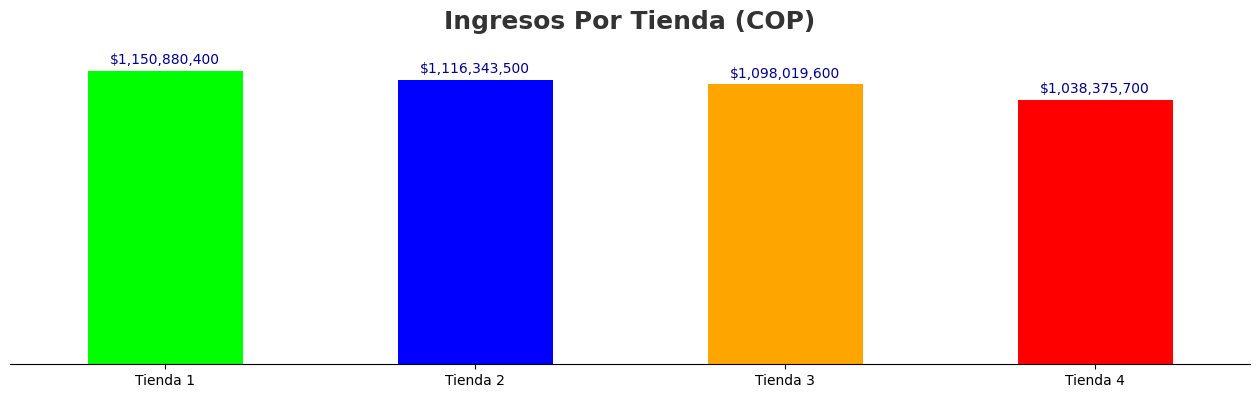

In [ ]:
colores = ['lime', 'blue', 'orange', 'red']
ax = Ingreso.plot(kind='bar', figsize=(16,4), color=colores)
ax.set_title('Ingresos Por Tienda (COP)', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.bar_label(ax.containers[0], fmt='${:,.0f}', padding=3, fontsize=10, color='darkblue')
ax.get_yaxis().set_visible(False) # Quita el eje Y
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False) # Quita bordes innecesarios
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')



###Distribución de categorías de productos en cada tienda

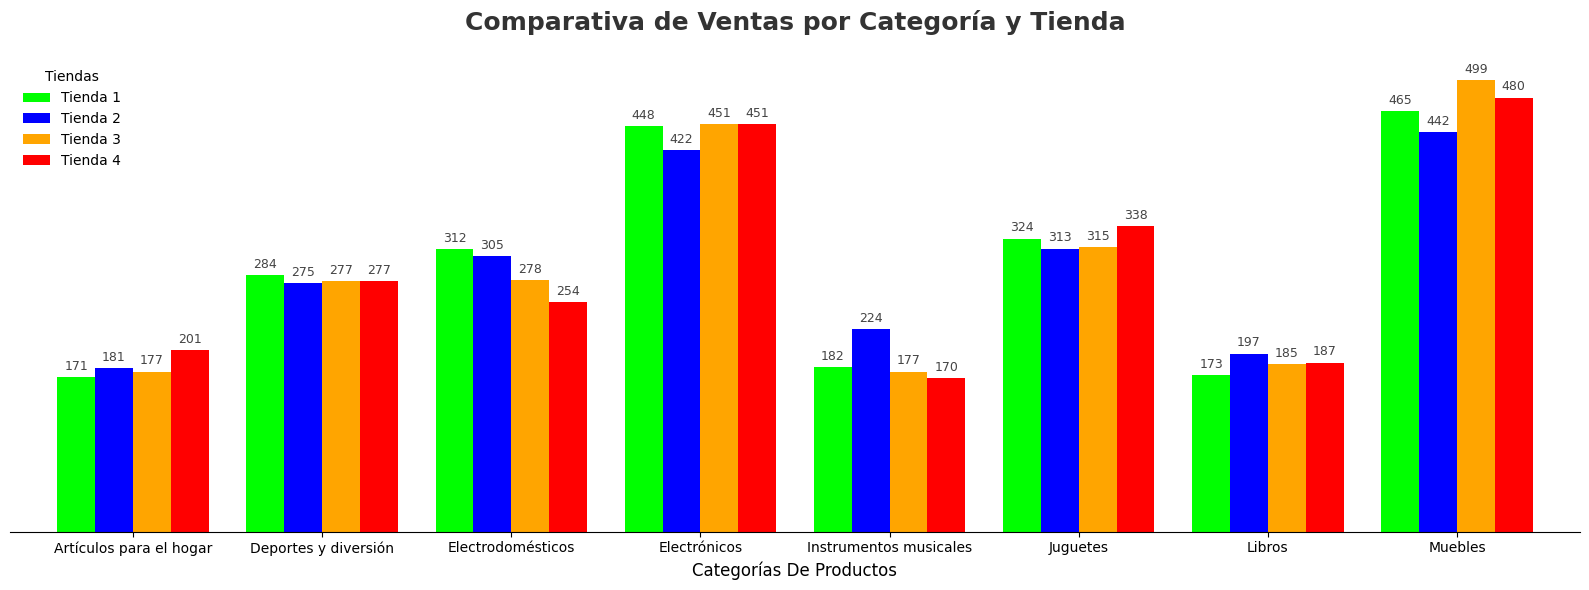

In [ ]:
ax2 = Categorias_total.plot(kind='bar', figsize=(16, 6), color=colores, width=0.8)
ax2.set_title('Comparativa de Ventas por Categoría y Tienda', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax2.set_xlabel('Categorías De Productos', fontsize=12)

for container in ax2.containers: #Añadimos etiquetas sobre las barras (bar_label)
    ax2.bar_label(container, padding=3, fontsize=9, color='#444444')

ax2.get_yaxis().set_visible(False) #Limpieza visual
for spine in ['top', 'right', 'left']:
    ax2.spines[spine].set_visible(False)

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, ha='center') # Rotación de etiquetas

plt.legend(title='Tiendas', frameon=False) #Configuración de la leyenda
plt.tight_layout()
plt.show()

###Comparativa de las opiniones de los clientes para cada tienda


/tmp/ipython-input-2055152242.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, ha='center')


[Text(0.0, 0, '0.0'),
 Text(0.5, 0, '0.5'),
 Text(1.0, 0, '1.0'),
 Text(1.5, 0, '1.5'),
 Text(2.0, 0, '2.0'),
 Text(2.5, 0, '2.5'),
 Text(3.0, 0, '3.0'),
 Text(3.5, 0, '3.5'),
 Text(4.0, 0, '4.0'),
 Text(4.5, 0, '4.5')]

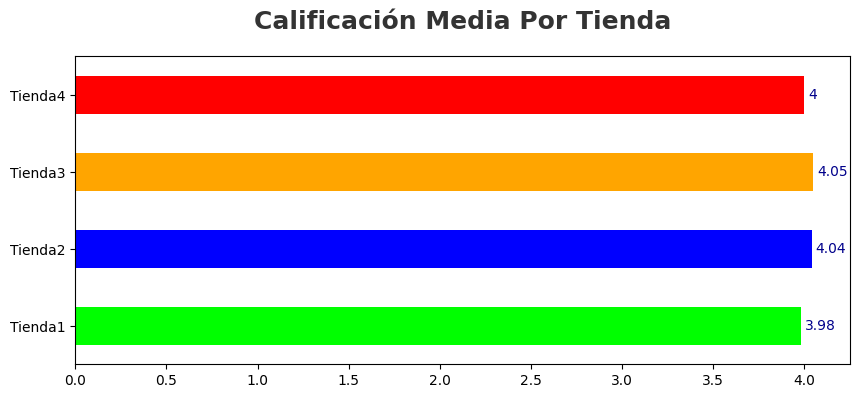

In [ ]:
ax3 = Media.plot(kind='barh', figsize=(10,4), color=colores)
ax3.set_title('Calificación Media Por Tienda', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax3.bar_label(ax3.containers[0], padding=3, fontsize=10, color='darkblue')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False) # Quita bordes innecesarios
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0, ha='center')

###los productos más vendidos y/o los costes de envío.

#**Informe de Análisis**

##**Introducción**

El propósito de este análisis es evaluar de manera comparativa las cuatro tiendas del Sr. Juan para determinar cuál de ellas presenta el desempeño menos favorable. Mediante el estudio de indicadores clave de rendimiento como los ingresos totales, la satisfacción del cliente y los costos logísticos, buscamos fundamentar una decisión objetiva que optimice el portafolio comercial del propietario.

##**Ingresos**

El análisis de ingresos totales muestra una tendencia decreciente desde la Tienda 1 hasta la Tienda 4.

Tienda 1: Es la líder en ventas con un total de $1,150,880,000 COP.

Tienda 4: Presenta el desempeño más bajo, con ingresos de $1,038,376,000 COP.

##**Calificaciones**

La percepción de los clientes es fundamental para la sostenibilidad a largo plazo.

Tienda 3 lidera este rubro con una calificación promedio de 4.05 estrellas.

Tienda 1 registra la calificación más baja (3.98), lo que indica posibles fricciones en la experiencia de compra a pesar de su alto volumen de ventas.

##**Costos de Envío**

El costo de envío impacta directamente en los márgenes de beneficio.

Tienda 4 es la más eficiente operativamente, con el costo promedio más bajo ($23,459).

Tienda 1 tiene la estructura logística más costosa, con un promedio de $26,018 por envío.

#**Conclusión y Recomendación**

Tras analizar todos los factores, la recomendación para el Sr. Juan es vender la Tienda 4.

Justificación de la decisión:

Menor Volumen de Ingresos: La Tienda 4 es la que menos aporta al flujo de caja total, situándose significativamente por debajo de la Tienda 1 (una diferencia de más de $112 millones de COP).

Bajo Impacto de Mercado: Aunque sus costos de envío son bajos, esto no compensa la falta de tracción en ventas. La categoría de "Instrumentos musicales" es su punto más débil, lo que sugiere una falta de afinidad con el mercado local de esa ubicación.

Costo de Oportunidad: Al vender la Tienda 4, el Sr. Juan puede liberar capital para reinvertir en la Tienda 1 (para mejorar su logística y calificación) o en la Tienda 3 (que ya cuenta con la mejor reputación entre los clientes).

En resumen, la Tienda 4 presenta el menor crecimiento y el retorno financiero más bajo del grupo, lo que la convierte en el activo ideal para ser descartado sin comprometer la estabilidad global del negocio.